In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import matplotlib.pyplot as plt #visualisasi
import seaborn as sns #visualisasi

In [8]:
data = pd.read_csv('/Data Bersih_Regresi.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Z_Score_X1  1171 non-null   float64
 1   Z_Score_X2  1171 non-null   float64
 2   Z_Score_X3  1171 non-null   float64
 3   Z_Score_X4  1171 non-null   float64
 4   Z_Score     1171 non-null   float64
dtypes: float64(5)
memory usage: 45.9 KB


In [9]:
data.isna().sum()

,0
Z_Score_X1,0
Z_Score_X2,0
Z_Score_X3,0
Z_Score_X4,0
Z_Score,0


In [10]:
data.describe()

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score
count,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000
mean,1.189553,0.153599,0.114889,1.525503,2.983543
std,1.526441,0.869998,0.470578,6.534279,6.833481
min,-9.828600,-5.624900,-8.276700,-0.591200,-9.627000
25%,0.001700,0.013050,0.026650,0.317450,0.764400
50%,0.860600,0.256200,0.135600,0.532000,2.480600
75%,2.315650,0.578200,0.275150,0.947300,3.950250
max,6.256000,2.600500,3.389700,153.064600,154.744600


In [ ]:
# Rename sebagian kolom
data = data.rename(columns={'Z_Score_X1': 'X1', 'Z_Score_X2': 'X2', 'Z_Score_X3': 'X3', 'Z_Score_X4': 'X4'})

In [11]:
data

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score
0,-0.1817,0.5921,0.3478,0.2727,1.0310
1,-0.1806,0.6244,0.1943,0.2912,0.9293
2,-0.2670,0.5252,0.0811,0.3226,0.6619
3,-0.2564,0.5998,0.3103,0.3258,0.9795
4,-0.1808,0.5149,0.0604,0.3265,0.7210
...,...,...,...,...,...
1166,2.5175,0.4250,0.1898,3.5440,6.6763
1167,2.8335,0.4275,0.0796,3.2158,6.5564
1168,2.3790,0.4487,0.0714,3.6915,6.5906
1169,2.4883,0.5276,0.2387,3.0053,6.2599


In [ ]:
data.describe()

,X1,X2,X3,X4,Z_Score
count,1171.000000,1171.000000,1171.000000,1171.000000,1171.000000
mean,1.189553,0.153599,0.114889,1.525503,2.983543
std,1.526441,0.869998,0.470578,6.534279,6.833481
min,-9.828600,-5.624900,-8.276700,-0.591200,-9.627000
25%,0.001700,0.013050,0.026650,0.317450,0.764400
50%,0.860600,0.256200,0.135600,0.532000,2.480600
75%,2.315650,0.578200,0.275150,0.947300,3.950250
max,6.256000,2.600500,3.389700,153.064600,154.744600


array([[<Axes: title={'center': 'Z_Score_X1'}>,
        <Axes: title={'center': 'Z_Score_X2'}>],
       [<Axes: title={'center': 'Z_Score_X3'}>,
        <Axes: title={'center': 'Z_Score_X4'}>],
       [<Axes: title={'center': 'Z_Score'}>, <Axes: >]], dtype=object)

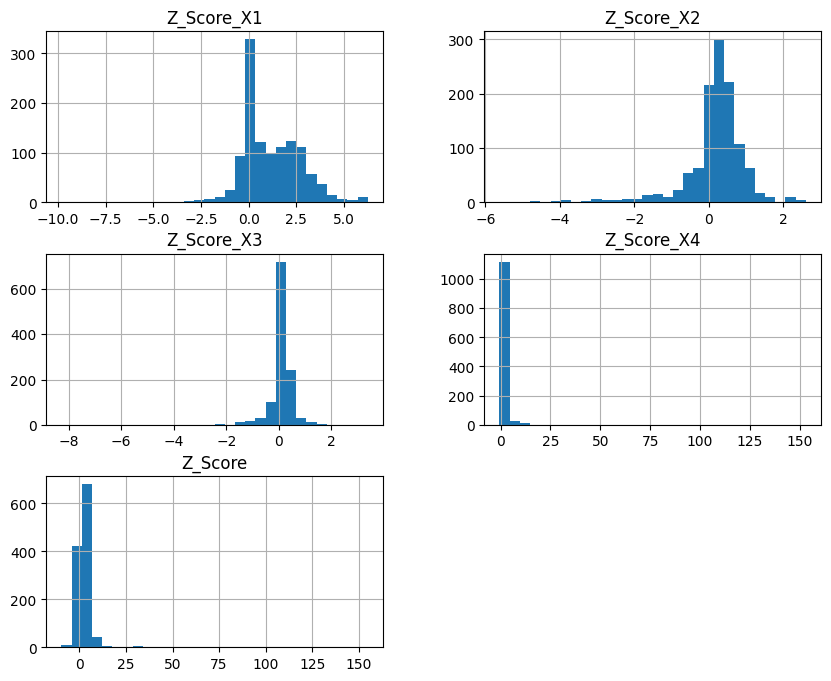

In [12]:
data.hist(bins=30, figsize=(10, 8))

In [13]:
# Create a label column based on conditions
def label_zscore(z):
    if z < 1.1:
        return 0  # Potential Bankruptcy
    elif 1.1 <= z <= 2.6:
        return 1  # Grey Area
    else:
        return 2  # Safe Zone

# Terapkan fungsi ke kolom Z_Score
data['Category'] = data['Z_Score'].apply(label_zscore)

In [14]:
data

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Category
0,-0.1817,0.5921,0.3478,0.2727,1.0310,0
1,-0.1806,0.6244,0.1943,0.2912,0.9293,0
2,-0.2670,0.5252,0.0811,0.3226,0.6619,0
3,-0.2564,0.5998,0.3103,0.3258,0.9795,0
4,-0.1808,0.5149,0.0604,0.3265,0.7210,0
...,...,...,...,...,...,...
1166,2.5175,0.4250,0.1898,3.5440,6.6763,2
1167,2.8335,0.4275,0.0796,3.2158,6.5564,2
1168,2.3790,0.4487,0.0714,3.6915,6.5906,2
1169,2.4883,0.5276,0.2387,3.0053,6.2599,2


In [15]:
data

,Z_Score_X1,Z_Score_X2,Z_Score_X3,Z_Score_X4,Z_Score,Category
0,-0.1817,0.5921,0.3478,0.2727,1.0310,0
1,-0.1806,0.6244,0.1943,0.2912,0.9293,0
2,-0.2670,0.5252,0.0811,0.3226,0.6619,0
3,-0.2564,0.5998,0.3103,0.3258,0.9795,0
4,-0.1808,0.5149,0.0604,0.3265,0.7210,0
...,...,...,...,...,...,...
1166,2.5175,0.4250,0.1898,3.5440,6.6763,2
1167,2.8335,0.4275,0.0796,3.2158,6.5564,2
1168,2.3790,0.4487,0.0714,3.6915,6.5906,2
1169,2.4883,0.5276,0.2387,3.0053,6.2599,2


In [16]:
data['Category'].value_counts()

,count
Category,
2,567
0,391
1,213


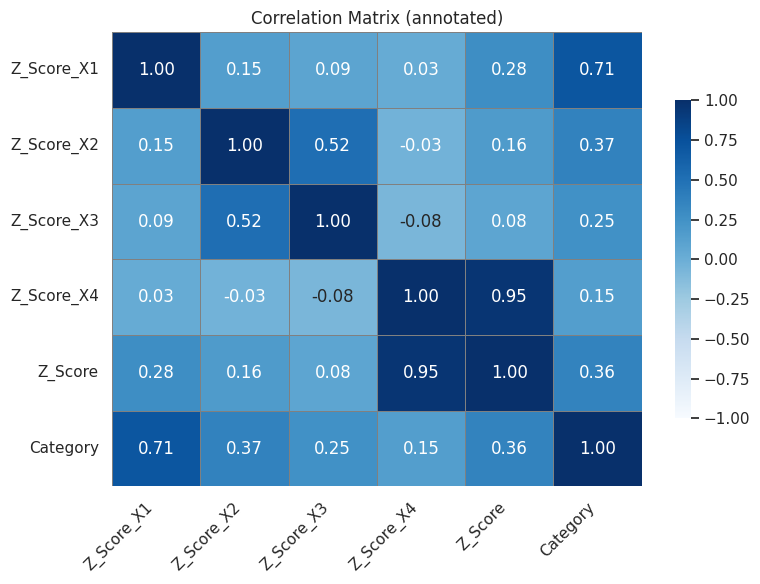

In [17]:
# Correlation heatmap dengan anotasi dan tema warna biru
plt.figure(figsize=(8, 6))
corr = data.select_dtypes(include=[np.number]).corr()  # hanya kolom numerik
sns.set(style='white')
mask = np.zeros_like(corr, dtype=bool)
# Tidak masking, tapi disiapkan jika ingin menyembunyikan diagonal/upper triangle
# mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink': 0.7})
plt.title('Correlation Matrix (annotated)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Rename sebagian kolom
data = data.rename(columns={'Z_Score_X1': 'X1', 'Z_Score_X2': 'X2', 'Z_Score_X3': 'X3', 'Z_Score_X4': 'X4'})

In [22]:
# Variabel independen dan dependen
X = data[['X1', 'X2', 'X3', 'X4']]
y = data['Category']
X = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

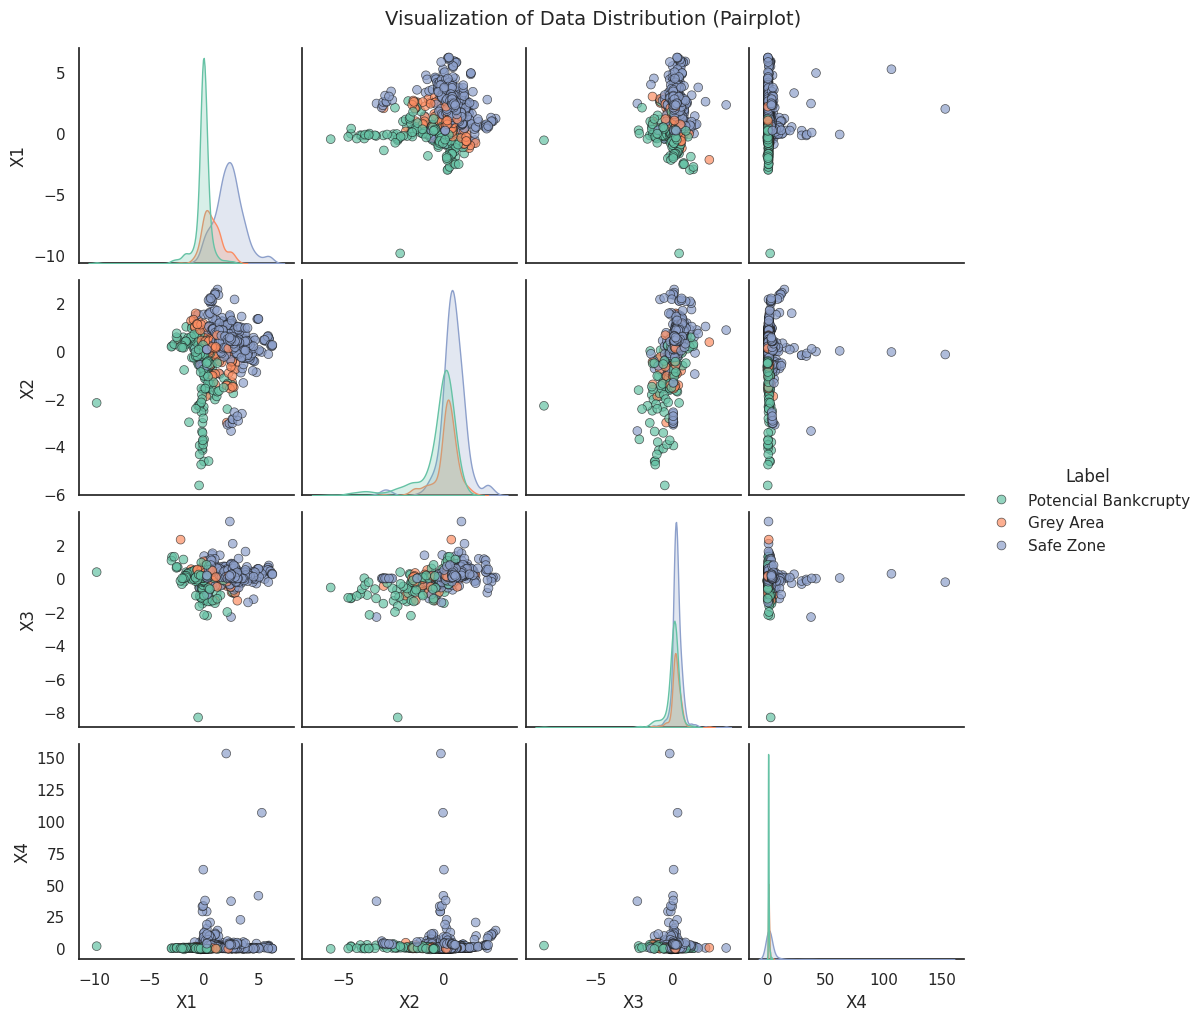

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove 'const' column if it exists
if 'const' in X.columns:
    X = X.drop(columns=['const'])

# Merge the features and labels for plotting
plot_data = X.copy()
plot_data['Label'] = y.replace({0: 'Potencial Bankcrupty', 1: 'Grey Area', 2: 'Safe Zone'})

# Pairplot
sns.pairplot(
    plot_data,
    hue='Label',
    diag_kind='kde',
    palette='Set2',
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'k'}
)
plt.suptitle("Visualization of Data Distribution (Pairplot)", y=1.02, fontsize=14)
plt.show()


## Mencari Method yang bisa digunakan atau tidak menghasilkan nilai nan pada hasil prediksinya

Parameter method menentukan algoritma optimisasi numerik yang digunakan untuk mencari nilai koefisien (parameter β) terbaik dari model logistik.

Tujuannya: mencari nilai koefisien β yang memaksimalkan fungsi log-likelihood dari model.
Untuk method-method yang dapat digunakan sudah tercantum didalam dokumentasi untuk MNLogit pada statsmodels pada link berikut ini:
https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.MNLogit.fit.html#statsmodels.discrete.discrete_model.MNLogit.fit

| Metode       | Nama Lengkap                        | Karakteristik                                 | Kelebihan                                 | Kekurangan                                    |
| :----------- | :---------------------------------- | :-------------------------------------------- | :---------------------------------------- | :-------------------------------------------- |
| `'newton'`   | Newton-Raphson                      | Menggunakan turunan pertama & kedua (Hessian) | Cepat konvergen untuk data kecil–menengah | Bisa gagal jika fungsi likelihood tidak halus |
| `'bfgs'`     | Broyden-Fletcher-Goldfarb-Shanno    | Menggunakan pendekatan Hessian                | Stabil dan umum digunakan                 | Sedikit lebih lambat                          |
| `'lbfgs'`    | Limited-memory BFGS                 | Versi hemat memori BFGS                       | Cocok untuk banyak variabel               | Bisa butuh tuning                             |
| `'cg'`       | Conjugate Gradient                  | Tidak menyimpan matriks Hessian               | Cocok untuk dataset besar                 | Kadang konvergensi lambat                     |
| `'nm'`       | Nelder-Mead Simplex                 | Berbasis pencarian simplex (tanpa turunan)    | Aman untuk fungsi non-diferensiabel       | Lebih lambat dan tidak selalu akurat          |
| `'powell'`   | Powell’s Method                     | Mengoptimalkan sepanjang arah tertentu        | Cukup robust untuk kasus non-linear       | Tidak efisien untuk model kompleks            |
| `'ncg'`      | Newton-Conjugate Gradient           | Kombinasi Newton dan conjugate gradient       | Kompromi antara kecepatan dan stabilitas  | Kadang susah konvergen                        |
| `'minimize'` | Wrapper `scipy.optimize.minimize()` | Dapat memilih metode lain di dalamnya         | Fleksibel                                 | Sedikit lebih lambat                          |


🔹 Attempting method: newton
Optimization terminated successfully.
         Current function value: nan
         Iterations 7

✅ Successfully fitted using method:: newton
Convergence Status: Converged
Number of Iterations   : 7
Pseudo R² (McFadden): nan
Log-Likelihood: nan
AIC: nan
BIC: nan
Category=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        nan         nan         nan
X1                nan        nan        nan        nan         nan         nan
X2                nan        nan        nan        nan         nan         nan
X3                nan        nan        nan        nan         nan         nan
X4                nan        nan        nan        nan         nan         nan
------------------------------------------------------------------------------
Category=2       coef    std err          z      P>|z|      [0.025      0.975

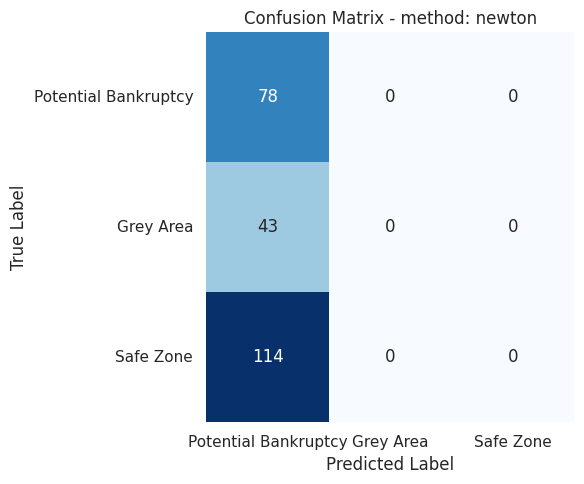



🔹 Attempting method: nm
Optimization terminated successfully.
         Current function value: 0.422973
         Iterations: 2174
         Function evaluations: 3064

✅ Successfully fitted using method:: nm
Convergence Status: Converged
Number of Iterations   : 2174
Pseudo R² (McFadden): 0.5883
Log-Likelihood: -395.9028
AIC: 811.8055
BIC: 860.2217
Category=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1982      0.241     -9.126      0.000      -2.670      -1.726
X1             1.8287      0.248      7.368      0.000       1.342       2.315
X2             4.0021      0.421      9.509      0.000       3.177       4.827
X3            -2.1654      0.484     -4.470      0.000      -3.115      -1.216
X4             1.9535      0.288      6.793      0.000       1.390       2.517
------------------------------------------------------------------------------
Category=2      

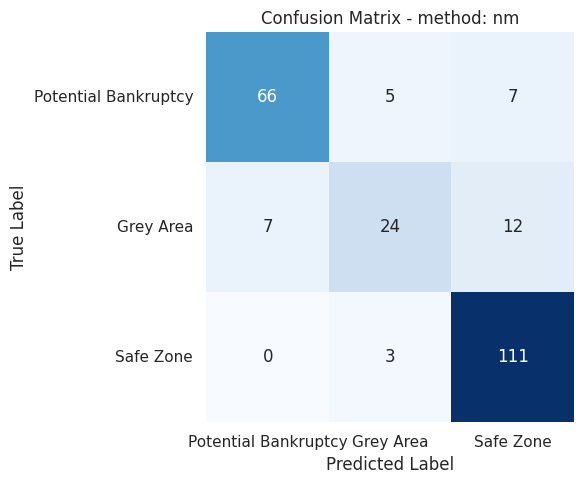



🔹 Attempting method: bfgs
         Current function value: nan
         Iterations: 14
         Function evaluations: 125
         Gradient evaluations: 125

✅ Successfully fitted using method:: bfgs
Convergence Status: Not Converged
Number of Iterations   : N/A
Pseudo R² (McFadden): nan
Log-Likelihood: nan
AIC: nan
BIC: nan
❌ Model failed to fit using method: bfgs
Error: need covariance of parameters for computing (unnormalized) covariances


🔹 Attempting method: lbfgs

✅ Successfully fitted using method:: lbfgs
Convergence Status: Not Converged
Number of Iterations   : 24
Pseudo R² (McFadden): 0.8076
Log-Likelihood: -185.0141
AIC: 390.0282
BIC: 438.4443
Category=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8245      0.285     -9.918      0.000      -3.383      -2.266
X1             2.7583      0.294      9.371      0.000       2.181       3.335
X2             2.2

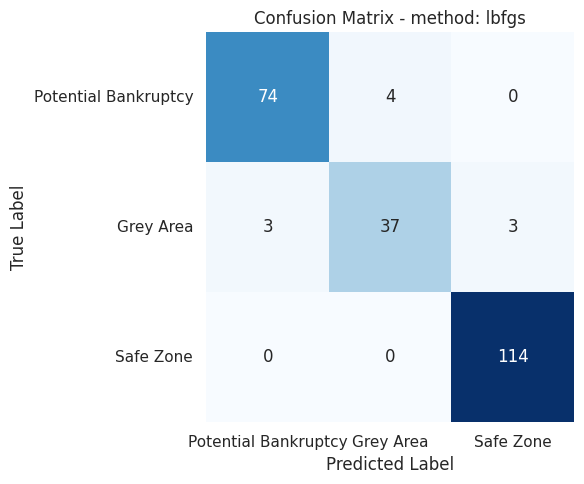



🔹 Attempting method: powell
         Current function value: nan
         Iterations: 6
         Function evaluations: 513

✅ Successfully fitted using method:: powell
Convergence Status: Not Converged
Number of Iterations   : 6
Pseudo R² (McFadden): nan
Log-Likelihood: nan
AIC: nan
BIC: nan
❌ Model failed to fit using method: powell
Error: need covariance of parameters for computing (unnormalized) covariances


🔹 Attempting method: cg
         Current function value: nan
         Iterations: 12
         Function evaluations: 239
         Gradient evaluations: 239

✅ Successfully fitted using method:: cg
Convergence Status: Not Converged
Number of Iterations   : N/A
Pseudo R² (McFadden): nan
Log-Likelihood: nan
AIC: nan
BIC: nan
❌ Model failed to fit using method: cg
Error: need covariance of parameters for computing (unnormalized) covariances


🔹 Attempting method: ncg
         Current function value: nan
         Iterations: 7
         Function evaluations: 22
         Gradient eva

In [24]:
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)
import numpy as np

# --- Nonaktifkan warning agar output bersih ---
warnings.filterwarnings("ignore")

# --- Daftar metode optimisasi yang ingin diuji ---
methods = ['newton', 'nm', 'bfgs', 'lbfgs', 'powell', 'cg', 'ncg', 'minimize']

# --- Label mapping ---
label_names = ['Potential Bankruptcy', 'Grey Area', 'Safe Zone']

# --- Looping untuk mencoba tiap metode ---
for m in methods:
    print("=" * 100)
    print(f"🔹 Attempting method: {m}")
    print("=" * 100)
    try:
        # Model MNLogit
        model = sm.MNLogit(y_train, X_train)
        result = model.fit(method=m, maxiter=100000, disp=True)

        # --- Ambil informasi konvergensi ---
        iterasi = result.mle_retvals.get('iterations', 'N/A')
        converged = result.mle_retvals.get('converged', False)

        # --- Model Evaluation ---
        print(f"\n✅ Successfully fitted using method:: {m}")
        print(f"Convergence Status: {'Converged' if converged else 'Not Converged'}")
        print(f"Number of Iterations   : {iterasi}")
        print(f"Pseudo R² (McFadden): {result.prsquared:.4f}")
        print(f"Log-Likelihood: {result.llf:.4f}")
        print(f"AIC: {result.aic:.4f}")
        print(f"BIC: {result.bic:.4f}")
        #print(result.summary())  #agar memunculkan informasi waktu
        print(result.summary().tables[1]) #agar tdk memunculkan waktu

        # --- Prediction ---
        y_pred_prob = result.predict(X_test)
        y_pred = np.argmax(y_pred_prob.values, axis=1)

        # --- Classification Evaluation ---
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        print("\n=== CLASSIFICATION METRICS ===")
        print(f"Accuracy   : {acc:.4f}")
        print(f"Precision  : {prec:.4f}")
        print(f"Recall     : {rec:.4f}")
        print(f"F1-Score   : {f1:.4f}")

        # --- Confusion Matrix ---
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_names, yticklabels=label_names
        )
        plt.title(f'Confusion Matrix - method: {m}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Model failed to fit using method: {m}")
        print(f"Error: {e}")

    print("=" * 100 + "\n\n")


## 🔹 Metode: L-BFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno)

### Status Optimisasi

* **Status Konvergensi:** *Belum konvergen*
* **Jumlah Iterasi:** 24 (cukup sedikit)

Meskipun tidak konvergen sempurna, model masih memberikan hasil evaluasi yang sangat baik. Hal ini menunjukkan bahwa proses optimisasi sudah mencapai **solusi yang cukup stabil**, namun mungkin masih sedikit jauh dari titik minimum global.

### Statistik Model

| Statistik            | Nilai      |
| -------------------- | ---------- |
| Pseudo R² (McFadden) | **0.8076** |
| Log-Likelihood       | -185.0141  |
| AIC                  | 390.0282   |
| BIC                  | 438.4443   |

Interpretasi:

* Nilai **Pseudo R² = 0.8076** menunjukkan model mampu menjelaskan sekitar 80% variasi dari data.
* Nilai **Log-Likelihood** relatif tinggi (lebih mendekati nol dibanding metode lain), menunjukkan model lebih baik dalam memprediksi data aktual.
* **AIC dan BIC** rendah, yang menandakan keseimbangan yang baik antara kompleksitas model dan goodness-of-fit.

### Metrik Klasifikasi

| Metrik    | Nilai  |
| --------- | ------ |
| Accuracy  | 0.9574 |
| Precision | 0.9568 |
| Recall    | 0.9574 |
| F1-Score  | 0.9569 |

Interpretasi:

* Model memiliki performa klasifikasi **sangat tinggi** dengan akurasi hampir **96%**.
* Nilai precision dan recall yang seimbang menandakan **stabilitas model dalam mengenali semua kelas** (tidak overfit ke satu kelas tertentu).

### Interpretasi Koefisien

* Semua variabel (X1–X4) memiliki **nilai signifikansi (p-value < 0.05)**, artinya masing-masing fitur memiliki kontribusi signifikan dalam membedakan antar kategori.
* Kenaikan pada variabel `X1`, `X2`, `X3`, dan `X4` meningkatkan kemungkinan perusahaan berada di kategori **lebih sehat** dibanding potensi bangkrut.

---

## 🔹 Metode: Nelder–Mead (NM)

### Status Optimisasi

* **Status Konvergensi:** *Berhasil konvergen*
* **Jumlah Iterasi:** 2174
  Metode NM memerlukan iterasi yang **sangat banyak** untuk mencapai konvergensi, tetapi berhasil stabil.

### Statistik Model

| Statistik            | Nilai      |
| -------------------- | ---------- |
| Pseudo R² (McFadden) | **0.5883** |
| Log-Likelihood       | -395.9028  |
| AIC                  | 811.8055   |
| BIC                  | 860.2217   |

Interpretasi:

* **Pseudo R² = 0.5883** menunjukkan model cukup baik, tetapi **tidak sebaik L-BFGS** dalam menjelaskan variasi data.
* Nilai **AIC dan BIC** jauh lebih tinggi dari metode L-BFGS → menandakan model ini **kurang efisien secara statistik**.

### Metrik Klasifikasi

| Metrik    | Nilai  |
| --------- | ------ |
| Accuracy  | 0.8553 |
| Precision | 0.8515 |
| Recall    | 0.8553 |
| F1-Score  | 0.8486 |

Interpretasi:

* Akurasi sebesar **85.5%** masih tergolong baik, namun **lebih rendah sekitar 10% dibanding metode L-BFGS**.
* Nilai precision dan recall cukup seimbang, menunjukkan stabilitas model tetap terjaga meskipun tingkat akurasi turun.

### Interpretasi Koefisien

* Sebagian besar variabel signifikan dengan arah pengaruh yang konsisten (positif untuk peningkatan peluang sehat).
* Namun, nilai koefisien pada beberapa fitur seperti `X3` menunjukkan arah negatif pada kelas tertentu, yang dapat menandakan **hubungan non-linear atau pengaruh kompleks antar fitur**.

---

## Kesimpulan Sementara

| Aspek              | L-BFGS                         | Nelder–Mead                |
| ------------------ | ------------------------------ | -------------------------- |
| Status Konvergensi | Belum konvergen (24 iterasi)   | Konvergen (2174 iterasi)   |
| Pseudo R²          | **0.8076 (Sangat tinggi)**     | 0.5883 (Sedang)            |
| Log-Likelihood     | **-185.01 (lebih baik)**       | -395.90                    |
| AIC                | **390.03 (lebih efisien)**     | 811.80                     |
| Akurasi            | **0.9574 (lebih tinggi)**      | 0.8553                     |
| Iterasi            | 24                             | 2174                       |

### Interpretasi Umum

* **L-BFGS memberikan hasil terbaik secara statistik dan prediktif**, meskipun belum mencapai konvergensi penuh.
* **Nelder-Mead memang konvergen penuh**, namun kualitas model (fit dan akurasi) jauh lebih rendah.
* Hal ini mengindikasikan bahwa **L-BFGS mungkin mendekati solusi optimal global lebih cepat**, hanya saja memerlukan **penyesuaian toleransi konvergensi atau regularisasi tambahan** untuk benar-benar stabil.
* Secara praktis, **L-BFGS tetap menjadi pilihan utama** untuk model MNLogit ini karena trade-off antara akurasi dan efisiensi iterasi yang sangat baik.

🔹 Constructing the MNLogit model with the 'lbfgs' optimization method
Log-Likelihood: -185.01407506622206
Pseudo R² (McFadden): 0.8075988002238041
                          MNLogit Regression Results                          
Dep. Variable:               Category   No. Observations:                  936
Model:                        MNLogit   Df Residuals:                      926
Method:                           MLE   Df Model:                            8
Date:                Fri, 17 Oct 2025   Pseudo R-squ.:                  0.8076
Time:                        18:16:59   Log-Likelihood:                -185.01
converged:                      False   LL-Null:                       -961.61
Covariance Type:            nonrobust   LLR p-value:                     0.000
Category=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8245      0.285     -9.918      0.000      -3.

<Figure size 1000x800 with 0 Axes>

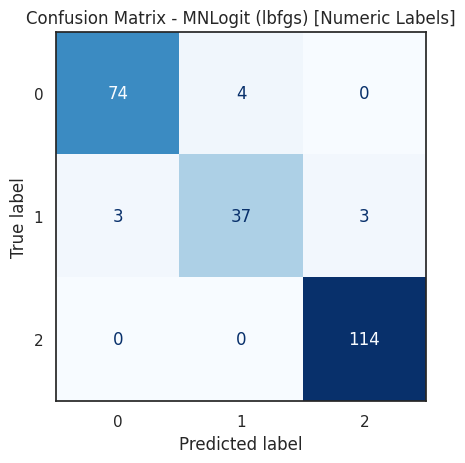

<Figure size 1000x800 with 0 Axes>

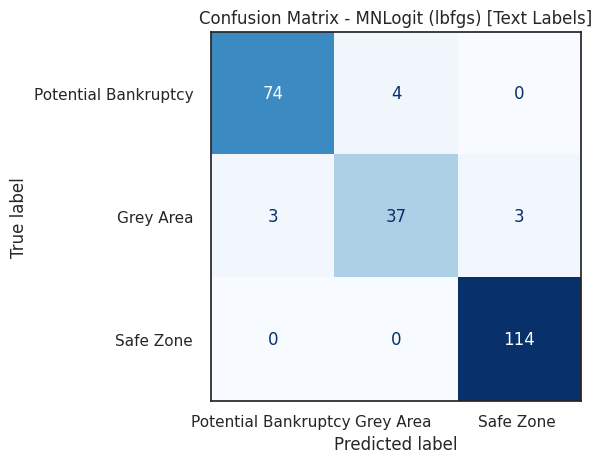

📊 MNLogit Model Evaluation (lbfgs)
Accuracy : 0.9574
Precision: 0.9568
Recall   : 0.9574
F1-Score : 0.9569


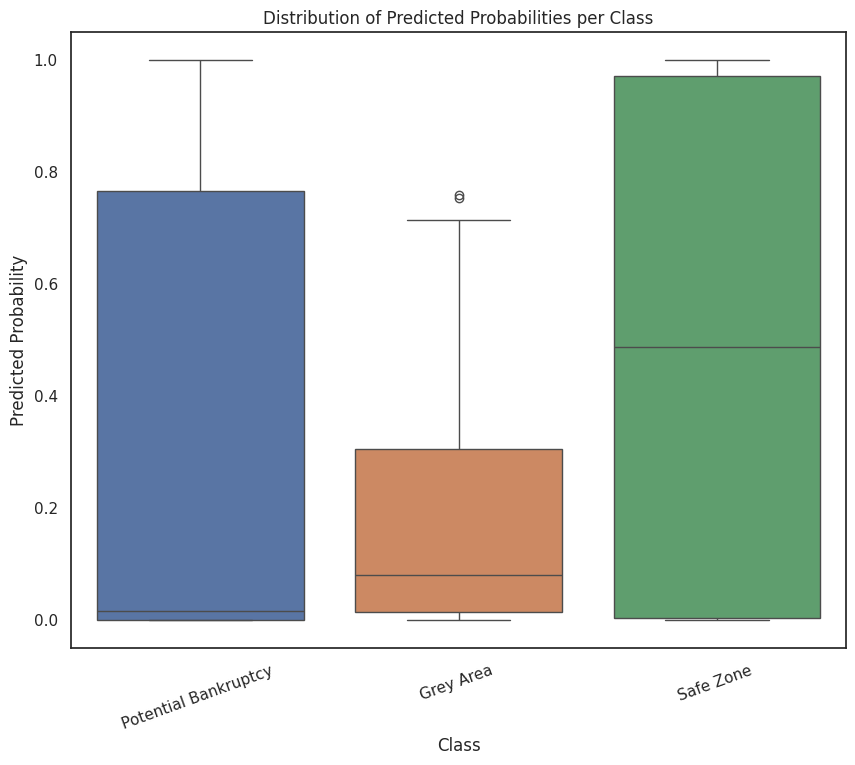

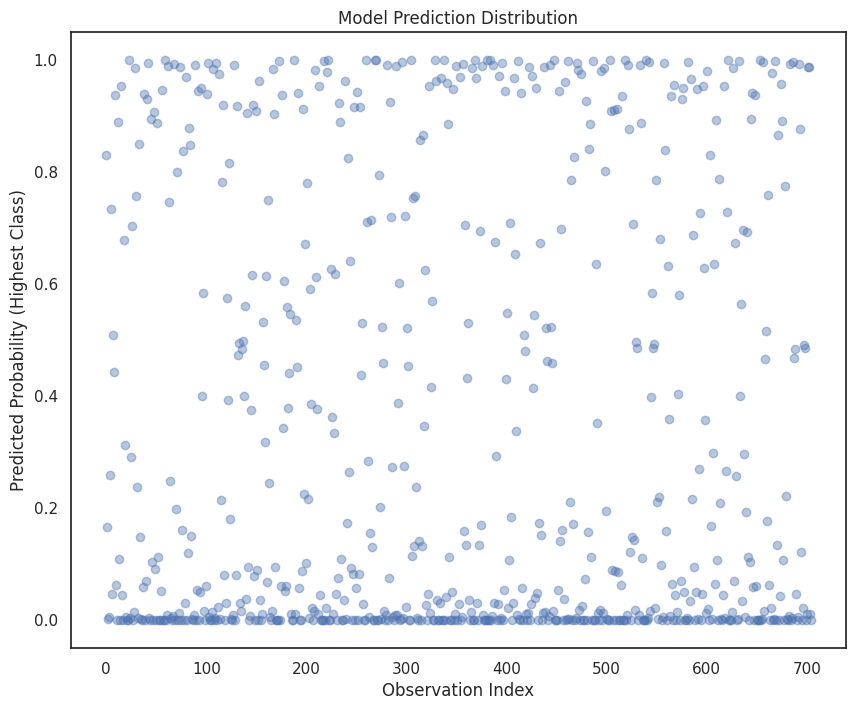



Summary of Prediction Errors
   True Label (Num)      True Label (Text)  Number of Errors
0                 0  Potential Bankruptcy                  4
1                 1             Grey Area                  6
2                 2             Safe Zone                  0


Prediction Results Table


,X1,X2,X3,X4,True_Label_Num,True_Label_Text,Pred_Label_Num,Pred_Label_Text,True?
242,-0.3690,0.6198,0.0843,0.3160,0,Potential Bankruptcy,0,Potential Bankruptcy,✅ True
573,0.5117,1.0833,0.6818,0.8240,2,Safe Zone,2,Safe Zone,✅ True
546,-0.5711,1.3532,0.4363,1.3357,1,Grey Area,1,Grey Area,✅ True
169,-0.1853,-0.0742,-0.0548,0.3726,0,Potential Bankruptcy,0,Potential Bankruptcy,✅ True
322,0.0190,0.1666,-0.1467,0.2256,0,Potential Bankruptcy,0,Potential Bankruptcy,✅ True
...,...,...,...,...,...,...,...,...,...
1152,2.1485,-3.0800,0.0000,5.9586,2,Safe Zone,2,Safe Zone,✅ True
251,-0.1607,0.2476,-0.0530,0.3532,0,Potential Bankruptcy,0,Potential Bankruptcy,✅ True
552,0.8649,0.6044,0.5087,0.6126,1,Grey Area,1,Grey Area,✅ True
914,2.5777,0.5857,0.3024,0.7775,2,Safe Zone,2,Safe Zone,✅ True


In [26]:
# =====================================
# 🧠 Multinomial Logistic Regression (MNLogit)
# Metode: lbfgs
# =====================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# =====================================
# 2️⃣ Model Building & Training
# =====================================
print("=" * 80)
print("🔹 Constructing the MNLogit model with the 'lbfgs' optimization method")
print("=" * 80)

model = sm.MNLogit(y_train, X_train)
result = model.fit(method='lbfgs', maxiter=5000, disp=True)

# =====================================
# 3️⃣ Statistical Evaluation of the Model
# =====================================
#print("\nAIC:", result.aic) //TIdak usah ditampilkan karena tidak dibandignkan
#print("BIC:", result.bic) //TIdak usah ditampilkan karena tidak dibandignkan
print("Log-Likelihood:", result.llf)
print("Pseudo R² (McFadden):", result.prsquared)
print(result.summary())

# =====================================
# 4️⃣ Prediction
# =====================================
y_pred_prob = result.predict(X_test)
y_pred = y_pred_prob.idxmax(axis=1)

# =====================================
# 5️⃣ Classification Evaluation
# =====================================

# --- Dynamic label assignment ---
label_map = {
    0: "Potential Bankruptcy ",
    1: "Grey Area ",
    2: "Safe Zone "
}

# Confusion Matrix (numerik)
cm_numeric = confusion_matrix(y_test, y_pred)
disp_num = ConfusionMatrixDisplay(confusion_matrix=cm_numeric)

plt.figure(figsize=(10, 8))
disp_num.plot(cmap='Blues', values_format='d', colorbar=False)
plt.title("Confusion Matrix - MNLogit (lbfgs) [Numeric Labels]")
plt.show()

# Confusion Matrix (teks)
cm_text = confusion_matrix(y_test, y_pred)
disp_text = ConfusionMatrixDisplay(confusion_matrix=cm_text, display_labels=list(label_map.values()))

plt.figure(figsize=(10, 8))
disp_text.plot(cmap='Blues', values_format='d', colorbar=False)
plt.title("Confusion Matrix - MNLogit (lbfgs) [Text Labels]")
plt.show()

# --- Compute evaluation metrics ----
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 80)
print("📊 MNLogit Model Evaluation (lbfgs)")
print("=" * 80)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# =====================================
# 6️⃣ Supplementary Visualization
# =====================================

# --- a. Predicted Class Probability Visualization ---
plt.figure(figsize=(10, 8))
sns.boxplot(data=y_pred_prob)
plt.title("Distribution of Predicted Probabilities per Class")
plt.xlabel("Class")
plt.ylabel("Predicted Probability")
plt.xticks(ticks=[0, 1, 2], labels=list(label_map.values()), rotation=20)
plt.show()

# --- b. Prediction Distribution Plot ---
if hasattr(result, 'normalized_cov_params'):
    plt.figure(figsize=(10, 8))
    plt.plot(result.predict(X_test).values.flatten(), 'o', alpha=0.4)
    plt.title("Model Prediction Distribution")
    plt.xlabel("Observation Index")
    plt.ylabel("Predicted Probability (Highest Class)")
    plt.show()

# =====================================
# 7️⃣ Prediction Results Table
# =====================================

hasil_prediksi = X_test.copy()
hasil_prediksi['True_Label_Num'] = y_test.values
hasil_prediksi['Pred_Label_Num'] = y_pred
hasil_prediksi['True?'] = np.where(
    hasil_prediksi['True_Label_Num'] == hasil_prediksi['Pred_Label_Num'],
    '✅ True', '❌ False'
)

# Map numeric labels to text
hasil_prediksi['True_Label_Text'] = hasil_prediksi['True_Label_Num'].map(label_map)
hasil_prediksi['Pred_Label_Text'] = hasil_prediksi['Pred_Label_Num'].map(label_map)

# Reorder columns for better readability
hasil_prediksi = hasil_prediksi[
    ['X1', 'X2', 'X3', 'X4',
     'True_Label_Num', 'True_Label_Text',
     'Pred_Label_Num', 'Pred_Label_Text',
     'True?']
]

# --- Error summary by label ---
error_summary = (
    hasil_prediksi.groupby(['True_Label_Num', 'True_Label_Text'])['True?']
    .apply(lambda x: (x == '❌ False').sum())
    .reset_index()
)
error_summary.columns = ['True Label (Num)', 'True Label (Text)', 'Number of Errors']

print("\n")
print("=" * 180)
print("Summary of Prediction Errors")
print("=" * 180)
print(error_summary)

# --- Example prediction results ---
print("\n")
print("=" * 180)
print("Prediction Results Table")
print("=" * 180)
hasil_prediksi

